# PVSG evaluation: where does the pipeline go wrong?

Compares the pipeline's output (`pvsg_run.ipynb`) with PVSG's human labels, **stage by stage**. No GPU needed.

1. **Objects (SAM2, stages 1–3):** pair each of our tracks with a human-labelled object by mask overlap over the whole video (**vIoU ≥ 0.5**, PVSG's threshold). Human objects with no partner were **missed**; our tracks with no partner are **extra** (or not labelled by PVSG: its labels are not complete).
2. **Names (DAM + LLM, stages 4–5, mapped to PVSG's classes in stage 7):** for each matched pair, is our class the human class?
3. **Relations (stage 6):** for each human relation, why it was or wasn't found:

| outcome | meaning | stage at fault |
|---|---|---|
| correct | same pair, same predicate, time overlap (tIoU) ≥ 0.5 | – |
| wrong time | same pair and predicate, tIoU < 0.5 | 6 (1 frame/s) |
| wrong predicate | the pair is related, but with another predicate | 6 (or the stage-7 mapping) |
| reversed | only the other direction (object → subject) was given | 6 |
| pair not related | both objects found, no relation between them | 6 |
| object missed | subject or object was never found | 1–3 |

4. **Strict vs lenient:** strict = exactly PVSG's word. Lenient = an LLM judge (like the SVG2 paper's) accepts synonyms and the same thing at another level of detail (tree / plant, child / baby), so vocabulary differences are not counted as errors.

In [17]:
import os, sys, json, glob, subprocess
import numpy as np, cv2
from PIL import Image
from scipy.optimize import linear_sum_assignment
REPO = "/kaggle/working/svg2-implementation"
if os.path.isdir(REPO):
    os.chdir(REPO)
sys.path.insert(0, os.path.join(os.getcwd(), "third_party/SVG2/pipeline")); sys.path.insert(0, os.path.join(os.getcwd(), "tools"))
import svg2_pipeline as P
import pvsg_data
import matplotlib.pyplot as plt
PVSG_ROOT = "/kaggle/tmp/pvsg" if os.path.isdir("/kaggle/tmp") else "/tmp/pvsg"
RUNS = "/kaggle/working/pvsg_runs"
OUT, DATA = "notes/pvsg", "data/pvsg"
os.makedirs(OUT, exist_ok=True); os.makedirs(DATA, exist_ok=True)
anno = pvsg_data.load_anno(PVSG_ROOT)
gt_by_id = {d["video_id"]: d for d in anno["data"]}
def run_file(v, name):
    """This session's run folder if it has the file, else the copy pushed to the repo by an earlier session."""
    p = os.path.join(RUNS, v, name)
    return p if os.path.exists(p) else os.path.join(DATA, v, name)

THIS_SESSION = sorted(v for v in (os.listdir(RUNS) if os.path.isdir(RUNS) else [])
                      if os.path.exists(os.path.join(RUNS, v, "pvsg_format.json")))
EARLIER = sorted(v for v in os.listdir(DATA) if os.path.exists(os.path.join(DATA, v, "matching.json"))
                 and os.path.exists(os.path.join(DATA, v, "pvsg_format.json")) and v not in THIS_SESSION)
VIDEOS = sorted(set(THIS_SESSION) | set(EARLIER))
print(f"evaluating {len(VIDEOS)} videos: {len(THIS_SESSION)} from this session, {len(EARLIER)} pushed earlier")
PERSON = {"adult", "child", "baby", "person", "man", "woman", "boy", "girl"}

evaluating 4 videos: 4 from this session, 0 pushed earlier


## 0. Map our names to PVSG's classes using the descriptions (stage 7, new version)

The first runs mapped each **bare name** to the closest PVSG class ("bush" → plant). Now the mapper also sees each object's **description and attributes**, so it can pick the right level of detail (a bush with a trunk → tree). Only internet calls, no GPU, about a minute per video. The first mapping is kept as `pvsg_format_wordonly.json` and compared below. Videos already re-mapped are skipped.

In [18]:
REMAP = True
todo = [v for v in THIS_SESSION if json.load(open(os.path.join(RUNS, v, "pvsg_format.json"))).get("mapping") != "context"]
if REMAP and todo:
    print("re-mapping:", todo)
    r = subprocess.run(["python3", "tools/pvsg_pipeline.py", "--pvsg_root", PVSG_ROOT, "--out", RUNS,
                        "--videos", *todo, "--redo_stage7"],
                       env={**os.environ, "CUDA_VISIBLE_DEVICES": ""}, capture_output=True, text=True)
    print("\n".join(l for l in r.stdout.splitlines() if "pvsg |" in l)[-2500:], r.stderr[-1500:])
print({v: json.load(open(run_file(v, "pvsg_format.json"))).get("mapping", "word") for v in VIDEOS})

{'0027_4571353789': 'context', '0028_4021064662': 'context', '0039_6951351121': 'context', '1122_3393449055': 'context'}


## 1. Objects: match our tracks to the human objects (vIoU over the whole video)

vIoU(ours, human) = (pixels both masks share, summed over all frames) / (pixels in either mask, summed over all frames). Pairs are chosen one-to-one (Hungarian), and kept if vIoU ≥ 0.5.

In [19]:
def match_objects(v):
    """vIoU matching from this session's SAM2 tracks; saved to data/pvsg/<video>/matching.json so that later
    sessions (after Kaggle deleted the tracks) can still include this video."""
    saved = os.path.join(DATA, v, "matching.json")
    if not os.path.exists(os.path.join(RUNS, v, "stage3_tracks_clean.json")):
        d = json.load(open(saved))
        return {int(g): tuple(x) for g, x in d["pairs"].items()}, {int(g): b for g, b in d["best"].items()}, d["ours"], d["frames"]
    result = _match_objects(v)
    pairs, best, ours, n = result
    os.makedirs(os.path.join(DATA, v), exist_ok=True)
    json.dump({"pairs": {str(g): list(x) for g, x in pairs.items()}, "best": {str(g): b for g, b in best.items()},
               "ours": ours, "frames": n}, open(saved, "w"))
    return result

def _match_objects(v):
    gt = gt_by_id[v]
    source = pvsg_data.video_source(anno, v)
    pngs = sorted(glob.glob(os.path.join(PVSG_ROOT, source, "masks", v, "*.png")))
    tracks = P.read_json(os.path.join(RUNS, v, "stage3_tracks_clean.json"))["objects"]
    gt_ids = [o["object_id"] for o in gt["objects"]]
    size = max(gt_ids + [0]) + 1
    inter = np.zeros((len(tracks), size)); area_ours = np.zeros(len(tracks)); area_gt = np.zeros(size)
    for t, png in enumerate(pngs):
        g = np.array(Image.open(png)).astype(np.int64)
        g[g >= size] = 0
        area_gt += np.bincount(g.ravel(), minlength=size)
        for i, o in enumerate(tracks):
            r = o["masks"][t] if t < len(o["masks"]) else None
            if not r:
                continue
            m = P.decode_rle(r).astype(bool)
            if m.shape != g.shape:
                m = cv2.resize(m.astype(np.uint8), (g.shape[1], g.shape[0]), interpolation=cv2.INTER_NEAREST) > 0
            area_ours[i] += m.sum()
            inter[i] += np.bincount(g[m], minlength=size)
    I = inter[:, gt_ids]
    viou = I / np.maximum(area_ours[:, None] + area_gt[gt_ids][None, :] - I, 1)
    rows, cols = linear_sum_assignment(-viou) if len(tracks) and gt_ids else ([], [])
    pairs = {gt_ids[c]: (tracks[r]["object_id"], float(viou[r, c])) for r, c in zip(rows, cols) if viou[r, c] >= 0.5}
    best = {gid: float(viou[:, j].max()) if len(tracks) else 0.0 for j, gid in enumerate(gt_ids)}
    return pairs, best, [o["object_id"] for o in tracks], len(pngs)

M = {}
for v in VIDEOS:
    M[v] = match_objects(v)
    pairs, best, ours, n = M[v]
    print(f"{v}: {len(pairs)}/{len(best)} human objects found (vIoU ≥ 0.5) by {len(ours)} tracks over {n} frames")

0027_4571353789: 10/16 human objects found (vIoU ≥ 0.5) by 57 tracks over 95 frames
0028_4021064662: 6/10 human objects found (vIoU ≥ 0.5) by 8 tracks over 95 frames
0039_6951351121: 4/17 human objects found (vIoU ≥ 0.5) by 36 tracks over 79 frames
1122_3393449055: 8/9 human objects found (vIoU ≥ 0.5) by 47 tracks over 92 frames


## 2. Objects and names

In [20]:
obj_rows, name_errors, stuff_as_person, stuff_as_thing, matched_objs = [], [], [], [], []
THINGS = set(anno["objects"]["thing"])
for v in VIDEOS:
    gt = gt_by_id[v]; pairs, best, ours, _ = M[v]
    pred = {o["object_id"]: o for o in json.load(open(run_file(v, "pvsg_format.json")))["objects"]}
    row = {"video": v, "human things": 0, "things found": 0, "human stuff": 0, "stuff found": 0,
           "our tracks": len(ours), "extra tracks": len(ours) - len(pairs), "named right": 0, "matched & described": 0}
    for o in gt["objects"]:
        kind = "things" if o["is_thing"] else "stuff"
        row[f"human {kind}"] += 1
        if o["object_id"] not in pairs:
            continue
        row[f"{kind} found"] += 1
        oid, vi = pairs[o["object_id"]]
        p = pred.get(oid)
        if p is None:
            continue
        row["matched & described"] += 1
        matched_objs.append({"video": v, "gt_id": o["object_id"], "human": o["category"], "is_thing": o["is_thing"],
                        "our_id": oid, "our_name": p["name"], "our_class": p["category"], "viou": round(vi, 2)})
        if not o["is_thing"] and p["category"] in THINGS:
            stuff_as_thing.append(matched_objs[-1])
        if p["category"] == o["category"]:
            row["named right"] += 1
        else:
            name_errors.append({"video": v, "gt_id": o["object_id"], "human": o["category"], "is_thing": o["is_thing"],
                                "our_id": oid, "our_name": p["name"], "our_class": p["category"], "viou": round(vi, 2)})
            if not o["is_thing"] and p["category"] in PERSON:
                stuff_as_person.append(name_errors[-1])
    obj_rows.append(row)

cols = list(obj_rows[0]) if obj_rows else []
print(" | ".join(cols))
for r in obj_rows:
    print(" | ".join(str(r[c]) for c in cols))
tot = {c: sum(r[c] for r in obj_rows) for c in cols[1:]}
print("\nTOTAL:", tot)
if tot:
    print(f"things found {tot['things found']}/{tot['human things']}, stuff found {tot['stuff found']}/{tot['human stuff']}, "
          f"named right {tot['named right']}/{tot['matched & described']}")
print(f"\nhuman STUFF (floor, ground, grass, …) that we named as an OBJECT: {len(stuff_as_thing)} "
      f"of {tot.get('stuff found', 0)} found (as a person: {len(stuff_as_person)})")
for e in stuff_as_thing:
    print(f"   {e['video']}: human {e['human']!r} → ours {e['our_name']!r} ({e['our_class']})")

old_right = new_right = old_n = 0
for m in matched_objs:
    f = run_file(m["video"], "pvsg_format_wordonly.json")
    if os.path.exists(f):
        old = {o["object_id"]: o for o in json.load(open(f))["objects"]}.get(m["our_id"])
        if old:
            old_n += 1; old_right += old["category"] == m["human"]; new_right += m["our_class"] == m["human"]
if old_n:
    print(f"\nmapping with bare names: {old_right}/{old_n} right → with descriptions: {new_right}/{old_n} right")
for e in stuff_as_person:
    print("  ", e)
print("\nall naming errors (human class → our open name → our mapped class):")
for e in name_errors:
    print(f"  {e['video']} gt {e['gt_id']:>3} {e['human']:>14} → {e['our_name']!r:30} → {e['our_class']}  (vIoU {e['viou']})")

video | human things | things found | human stuff | stuff found | our tracks | extra tracks | named right | matched & described
0027_4571353789 | 12 | 9 | 4 | 1 | 57 | 47 | 8 | 10
0028_4021064662 | 8 | 4 | 2 | 2 | 8 | 2 | 4 | 6
0039_6951351121 | 14 | 2 | 3 | 2 | 36 | 32 | 2 | 4
1122_3393449055 | 8 | 8 | 1 | 0 | 47 | 39 | 6 | 8

TOTAL: {'human things': 42, 'things found': 23, 'human stuff': 10, 'stuff found': 5, 'our tracks': 148, 'extra tracks': 120, 'named right': 20, 'matched & described': 28}
things found 23/42, stuff found 5/10, named right 20/28

human STUFF (floor, ground, grass, …) that we named as an OBJECT: 4 of 5 found (as a person: 2)
   0027_4571353789: human 'tree' → ours 'bush' (plant)
   0028_4021064662: human 'ground' → ours 'car' (car)
   0028_4021064662: human 'grass' → ours 'child' (child)
   0039_6951351121: human 'grass' → ours 'person' (adult)

mapping with bare names: 19/28 right → with descriptions: 20/28 right
   {'video': '0028_4021064662', 'gt_id': 2, 'human'

## 3. Relations: for every human relation, what happened

In [21]:
def frames_of(spans):
    s = set()
    for a, b in spans:
        s.update(range(int(a), int(b) + 1))
    return s

rel_rows, examples = [], []
OUTCOMES = ["correct", "wrong time", "wrong predicate", "reversed", "pair not related", "object missed"]
for v in VIDEOS:
    gt = gt_by_id[v]; pairs, _, _, _ = M[v]
    ours = json.load(open(run_file(v, "pvsg_format.json")))
    our_of = {g: o for g, (o, _) in pairs.items()}
    by_pair = {}
    for s, o, p, spans in ours["relations"]:
        by_pair.setdefault((s, o), {}).setdefault(p, set()).update(frames_of(spans))
    count = dict.fromkeys(OUTCOMES, 0)
    for s, o, p, spans in gt["relations"]:
        if s not in our_of or o not in our_of:
            out = "object missed"
        else:
            a, b = our_of[s], our_of[o]
            cand = by_pair.get((a, b), {})
            if not cand:
                out = "reversed" if by_pair.get((b, a)) else "pair not related"
            elif p not in cand:
                out = "wrong predicate"
                examples.append((v, s, o, p, sorted(cand)))
            else:
                g, f = frames_of(spans), cand[p]
                out = "correct" if len(g & f) / max(len(g | f), 1) >= 0.5 else "wrong time"
        count[out] += 1
    n_ours = len(ours["relations"])
    matched = {o for o, _ in pairs.values()}
    checkable = [r for r in ours["relations"] if r[0] in matched and r[1] in matched]
    inv = {o: g for g, (o, _) in pairs.items()}
    gt_set = {(s, o, p) for s, o, p, _ in gt["relations"]}
    right_pair_pred = sum((inv[r[0]], inv[r[1]], r[2]) in gt_set for r in checkable)
    none_mapped = sum(r["pvsg_predicate"] == "none" for r in ours["relations_open"])
    rel_rows.append({"video": v, "human relations": len(gt["relations"]), **count, "our relations": n_ours,
                     "ours between found objects": len(checkable), "of those also in PVSG (any time)": right_pair_pred,
                     "our predicates with no PVSG match": none_mapped})

cols = list(rel_rows[0]) if rel_rows else []
for r in rel_rows:
    print(r)
tot_rel = {c: sum(r[c] for r in rel_rows) for c in cols[1:]}
print("\nTOTAL:", tot_rel)
if tot_rel and tot_rel["human relations"]:
    n = tot_rel["human relations"]
    print("\nWhat happened to the human relations:")
    for k in OUTCOMES:
        print(f"  {k:18} {tot_rel[k]:4d}  ({tot_rel[k] / n:.0%})")
    print(f"\nrecall (pair + predicate + time) = {tot_rel['correct'] / n:.1%};  ignoring time = {(tot_rel['correct'] + tot_rel['wrong time']) / n:.1%}")
print("\nwrong-predicate examples (human predicate → what we said for that pair):")
for e in examples[:15]:
    print("  ", e)

{'video': '0027_4571353789', 'human relations': 17, 'correct': 1, 'wrong time': 1, 'wrong predicate': 1, 'reversed': 0, 'pair not related': 4, 'object missed': 10, 'our relations': 9, 'ours between found objects': 6, 'of those also in PVSG (any time)': 2, 'our predicates with no PVSG match': 7}
{'video': '0028_4021064662', 'human relations': 18, 'correct': 0, 'wrong time': 0, 'wrong predicate': 4, 'reversed': 0, 'pair not related': 8, 'object missed': 6, 'our relations': 9, 'ours between found objects': 7, 'of those also in PVSG (any time)': 0, 'our predicates with no PVSG match': 3}
{'video': '0039_6951351121', 'human relations': 13, 'correct': 0, 'wrong time': 0, 'wrong predicate': 0, 'reversed': 0, 'pair not related': 1, 'object missed': 12, 'our relations': 10, 'ours between found objects': 0, 'of those also in PVSG (any time)': 0, 'our predicates with no PVSG match': 5}
{'video': '1122_3393449055', 'human relations': 11, 'correct': 2, 'wrong time': 1, 'wrong predicate': 6, 'revers

## 4. Strict vs lenient (LLM judge)

The judge sees the human label and **our own word** (before mapping) and says: identical, synonym, broader, narrower, related or mismatch.
- **strict:** our mapped class is exactly PVSG's;
- **close:** strict, or identical / synonym / broader / narrower (the same thing at another level of detail);
- **lenient:** close, or related (the SVG2 paper's lenient score: everything except mismatch).

For relations, the judge compares the human predicate with **every** predicate we gave for that pair (also the ones the mapping dropped).

In [22]:
from pvsg_judge import judge, nim_client, CLOSE, LENIENT
JUDGE_MODEL = "moonshotai/kimi-k3"
client = nim_client(240)

# objects
cats = judge(client, JUDGE_MODEL, [("object", m["human"], m["our_name"]) for m in matched_objs])
for m, c in zip(matched_objs, cats):
    m["judge"] = c
n_obj = len(matched_objs)
obj_score = {"strict": sum(m["our_class"] == m["human"] for m in matched_objs),
             "close": sum(m["our_class"] == m["human"] or m["judge"] in CLOSE for m in matched_objs),
             "lenient": sum(m["our_class"] == m["human"] or m["judge"] in LENIENT for m in matched_objs)}
print(f"OBJECT NAMES ({n_obj} matched objects):  " + "   ".join(f"{k} {v}/{n_obj} = {v / max(n_obj, 1):.0%}" for k, v in obj_score.items()))
print("\nhuman class → our word (mapped class): judge")
for m in matched_objs:
    if m["our_class"] != m["human"]:
        print(f"  {m['human']:>14} → {m['our_name']!r:28} ({m['our_class']}): {m['judge']}")

# relations
rel_items, rel_where = [], []
per_video = {}
for v in VIDEOS:
    gt = gt_by_id[v]; pairs, _, _, _ = M[v]
    our_of = {g: o for g, (o, _) in pairs.items()}
    ours = json.load(open(run_file(v, "pvsg_format.json")))
    open_by_pair = {}
    for r in ours["relations_open"]:
        open_by_pair.setdefault((r["subject"], r["object"]), []).append(r)
    per_video[v] = (gt, our_of, open_by_pair)
    for k, (s, o, p, spans) in enumerate(gt["relations"]):
        if s in our_of and o in our_of:
            for r in open_by_pair.get((our_of[s], our_of[o]), []):
                rel_items.append(("relation", p, r["predicate"])); rel_where.append((v, k, r))
rel_cats = judge(client, JUDGE_MODEL, rel_items) if rel_items else []
ok = {}
for (v, k, r), c in zip(rel_where, rel_cats):
    ok.setdefault((v, k), []).append((r, c))

n_rel = sum(len(per_video[v][0]["relations"]) for v in VIDEOS)
rel_score = {}
for level, accept in (("close", CLOSE), ("lenient", LENIENT)):
    with_time = without_time = 0
    for v in VIDEOS:
        gt = per_video[v][0]
        for k, (s, o, p, spans) in enumerate(gt["relations"]):
            good = [r for r, c in ok.get((v, k), []) if c in accept or r["pvsg_predicate"] == p]
            if not good:
                continue
            without_time += 1
            f = set().union(*(frames_of(r["frames"]) for r in good))
            g = frames_of(spans)
            with_time += len(g & f) / max(len(g | f), 1) >= 0.5
    rel_score[level] = {"with time (tIoU ≥ 0.5)": with_time, "ignoring time": without_time}
rel_score["strict"] = {"with time (tIoU ≥ 0.5)": tot_rel.get("correct", 0),
                       "ignoring time": tot_rel.get("correct", 0) + tot_rel.get("wrong time", 0)}
print(f"\nRELATIONS ({n_rel} human relations):")
for level in ("strict", "close", "lenient"):
    d = rel_score[level]
    print(f"  {level:8} " + "   ".join(f"{k}: {x}/{n_rel} = {x / max(n_rel, 1):.0%}" for k, x in d.items()))
print("\n(the ceiling: relations whose two objects were both found =",
      sum(1 for v in VIDEOS for s, o, _, _ in per_video[v][0]["relations"] if s in per_video[v][1] and o in per_video[v][1]), ")")

OBJECT NAMES (28 matched objects):  strict 20/28 = 71%   close 21/28 = 75%   lenient 24/28 = 86%

human class → our word (mapped class): judge
            tree → 'bush'                       (plant): related
           table → 'tablecloth'                 (cloth): related
          ground → 'car'                        (car): mismatch
           grass → 'child'                      (child): mismatch
           grass → 'person'                     (adult): mismatch
           adult → 'football'                   (ball): mismatch
           child → 'baby'                       (baby): narrower
           table → 'countertop'                 (countertop): related


    moonshotai/kimi-k3 attempt 1 (json_object) failed after 11 s: json_object: no JSON in reply ('{"!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!')



RELATIONS (59 human relations):
  strict   with time (tIoU ≥ 0.5): 3/59 = 5%   ignoring time: 5/59 = 8%
  close    with time (tIoU ≥ 0.5): 3/59 = 5%   ignoring time: 5/59 = 8%
  lenient  with time (tIoU ≥ 0.5): 5/59 = 8%   ignoring time: 9/59 = 15%

(the ceiling: relations whose two objects were both found = 31 )


## 5. Final scores, as in the SVG2 paper (object accuracy, relation recall, triplet recall)

For every **human** label (so missed objects count as failures):
- **object:** the human object was found (vIoU ≥ 0.5) and named right;
- **relation:** subject and object found, predicate right, time overlap tIoU ≥ 0.5 (also shown ignoring time);
- **triplet:** the relation is right **and** both the subject and the object are named right.

"Right" at three levels: strict (exact PVSG word), close (+ synonyms / broader / narrower), lenient (+ related; the paper's main tables use lenient).

In [23]:
name_by = {(m["video"], m["gt_id"]): m for m in matched_objs}

def name_ok(v, gid, level):
    m = name_by.get((v, gid))
    if m is None:
        return False
    if m["our_class"] == m["human"]:
        return True
    return (level == "close" and m.get("judge") in CLOSE) or (level == "lenient" and m.get("judge") in LENIENT)

def rel_frames(v, k, level):
    gt, our_of, open_by_pair = per_video[v]
    s, o, p, spans = gt["relations"][k]
    if s not in our_of or o not in our_of:
        return None
    if level == "strict":
        good = [r for r in open_by_pair.get((our_of[s], our_of[o]), []) if r["pvsg_predicate"] == p]
    else:
        accept = CLOSE if level == "close" else LENIENT
        good = [r for r, c in ok.get((v, k), []) if c in accept or r["pvsg_predicate"] == p]
    return set().union(*(frames_of(r["frames"]) for r in good)) if good else None

n_gt_obj = sum(len(gt_by_id[v]["objects"]) for v in VIDEOS)
final = {}
for level in ("strict", "close", "lenient"):
    objs = sum(name_ok(v, o["object_id"], level) for v in VIDEOS for o in gt_by_id[v]["objects"])
    rel_t = rel_any = trip_t = trip_any = 0
    for v in VIDEOS:
        for k, (s, o, p, spans) in enumerate(per_video[v][0]["relations"]):
            f = rel_frames(v, k, level)
            if f is None:
                continue
            g = frames_of(spans)
            in_time = len(g & f) / max(len(g | f), 1) >= 0.5
            names = name_ok(v, s, level) and name_ok(v, o, level)
            rel_any += 1; rel_t += in_time; trip_any += names; trip_t += names and in_time
    final[level] = {"object accuracy": objs / max(n_gt_obj, 1),
                    "relation recall": rel_t / max(n_rel, 1), "relation recall, ignoring time": rel_any / max(n_rel, 1),
                    "triplet recall": trip_t / max(n_rel, 1), "triplet recall, ignoring time": trip_any / max(n_rel, 1)}

cols = list(final["strict"])
print(f"{n_gt_obj} human objects, {n_rel} human relations, {len(VIDEOS)} videos\n")
print(f"{'':9}" + "".join(f"{c:>32}" for c in cols))
for level, d in final.items():
    print(f"{level:9}" + "".join(f"{d[c]:>32.1%}" for c in cols))
print("\nFor orientation, the SVG2 paper on PVSG (lenient, tIoU 0.5) — a different setting, see the note below:")
print("  Table 2  (human trajectories given):  GPT-5  object 54.2  relation 18.3  triplet 16.6 | TraSeR  72.7 / 16.9 / 16.1")
print("  Table 12 (pipeline masks, IoU ≥ 0.3, VidOR part): TraSeR  object 63.4  relation 13.4  triplet 10.0")

52 human objects, 59 human relations, 4 videos

                          object accuracy                 relation recall  relation recall, ignoring time                  triplet recall   triplet recall, ignoring time
strict                              38.5%                            5.1%                            8.5%                            3.4%                            5.1%
close                               40.4%                            5.1%                            8.5%                            5.1%                            8.5%
lenient                             46.2%                            8.5%                           15.3%                            8.5%                           15.3%

For orientation, the SVG2 paper on PVSG (lenient, tIoU 0.5) — a different setting, see the note below:
  Table 2  (human trajectories given):  GPT-5  object 54.2  relation 18.3  triplet 16.6 | TraSeR  72.7 / 16.9 / 16.1
  Table 12 (pipeline masks, IoU ≥ 0.3, VidOR part):

**Comparing with the paper (careful):** the paper scores a *model* (TraSeR or GPT-5) that is given trajectories; Table 12 matches predicted masks at IoU ≥ 0.3. Here we score the **data-generation pipeline itself** (the labels SVG2 would contain), with our own SAM2 tracks matched at the stricter vIoU ≥ 0.5, relations from Kimi K3 with 8 frames (the paper: GPT-5, up to 24), and object accuracy over **all** human objects (missed ones count as wrong).

## 6. What the naming errors look like
Human mask in red; title = human class vs our name. Up to 6 errors, stuff first.

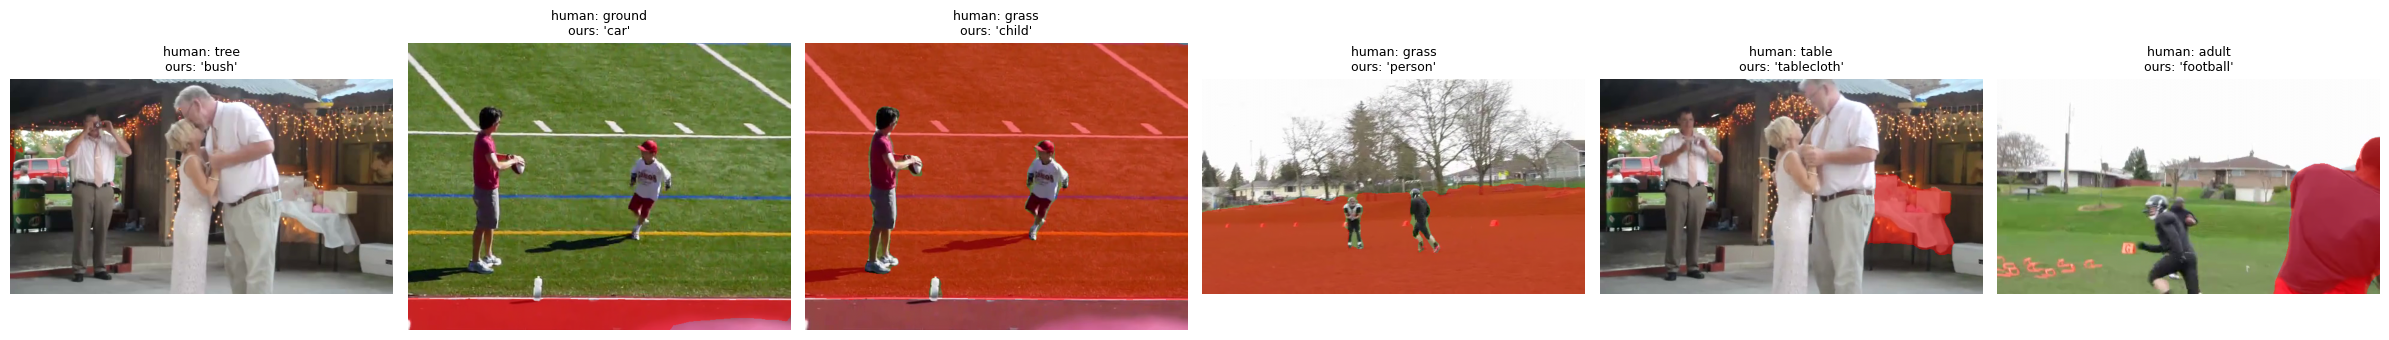

In [24]:
def on_disk(e):
    src = pvsg_data.video_source(anno, e["video"])
    return os.path.exists(os.path.join(PVSG_ROOT, src, "videos", e["video"] + ".mp4"))
shown = sorted([e for e in name_errors if on_disk(e)], key=lambda e: e["is_thing"])[:6]
if shown:
    fig, axes = plt.subplots(1, len(shown), figsize=(4 * len(shown), 4), squeeze=False)
    for ax, e in zip(axes[0], shown):
        source = pvsg_data.video_source(anno, e["video"])
        pngs = sorted(glob.glob(os.path.join(PVSG_ROOT, source, "masks", e["video"], "*.png")))
        vis = [t for t, p in enumerate(pngs) if (np.array(Image.open(p)) == e["gt_id"]).any()]
        t = vis[len(vis) // 2]
        cap = cv2.VideoCapture(os.path.join(PVSG_ROOT, source, "videos", e["video"] + ".mp4"))
        cap.set(cv2.CAP_PROP_POS_FRAMES, t); ok, fr = cap.read(); cap.release()
        im = cv2.cvtColor(fr, cv2.COLOR_BGR2RGB).astype(float) / 255
        m = np.array(Image.open(pngs[t])) == e["gt_id"]
        if m.shape != im.shape[:2]:
            m = cv2.resize(m.astype(np.uint8), (im.shape[1], im.shape[0]), interpolation=cv2.INTER_NEAREST) > 0
        im[m] = 0.5 * im[m] + 0.5 * np.array([1, 0, 0])
        ax.imshow(im); ax.axis("off")
        ax.set_title(f"human: {e['human']}\nours: {e['our_name'][:28]!r}", fontsize=9)
    fig.tight_layout(); fig.savefig(f"{OUT}/naming_errors.png", dpi=70); plt.show()
else:
    print("no naming errors among matched objects")

## 7. Save (small files only) and push

In [25]:
import shutil
for v in VIDEOS:
    os.makedirs(os.path.join(DATA, v), exist_ok=True)
    for f in ("pvsg_format.json", "pvsg_format_wordonly.json", "stage4_descriptions.json", "status.json"):
        if os.path.exists(os.path.join(RUNS, v, f)):
            shutil.copy(os.path.join(RUNS, v, f), os.path.join(DATA, v, f))
summary = {"videos": VIDEOS, "objects": obj_rows, "objects_total": tot, "naming_errors": name_errors,
           "stuff_named_as_person": stuff_as_person, "stuff_named_as_object": stuff_as_thing,
           "matched_objects": matched_objs, "names_strict_close_lenient": obj_score,
           "names_bare_mapping_vs_descriptions": {"n": old_n, "bare": old_right, "descriptions": new_right},
           "relations": rel_rows, "relations_total": tot_rel, "relations_strict_close_lenient": rel_score,
           "final_scores": final}
json.dump(summary, open(f"{OUT}/eval_summary.json", "w"), indent=1)
L = ["# PVSG, Option A: pipeline vs human labels", "", f"Videos: {', '.join(VIDEOS)}", "",
     "## Objects", "", "| " + " | ".join(obj_rows[0]) + " |", "|" + "---|" * len(obj_rows[0])]
L += ["| " + " | ".join(str(x) for x in r.values()) + " |" for r in obj_rows]
L += ["", f"Human stuff (floor, ground, grass, …) named as an object: {len(stuff_as_thing)} of {tot.get('stuff found', 0)} found "
      f"(as a person: {len(stuff_as_person)})", ""]
L += [f"- {e['video']}: human `{e['human']}` → ours `{e['our_name']}` (`{e['our_class']}`)" for e in stuff_as_thing]
L += ["", "## Final scores (per human label; missed objects count as failures)", "",
      "| | " + " | ".join(final["strict"]) + " |", "|---|" + "---|" * len(final["strict"])]
L += [f"| {lv} | " + " | ".join(f"{x:.1%}" for x in d.values()) + " |" for lv, d in final.items()]
L += ["", f"{n_gt_obj} human objects, {n_rel} human relations. SVG2 paper, PVSG, lenient, tIoU 0.5 (a model given trajectories, "
      "not the pipeline): GPT-5 object 54.2 / relation 18.3 / triplet 16.6 (Table 2); TraSeR with pipeline masks 63.4 / 13.4 / 10.0 (Table 12)."]
L += ["", "## Names: strict vs lenient", "", "| | right | of |", "|---|---|---|"]
L += [f"| {k} | {v_} | {n_obj} |" for k, v_ in obj_score.items()]
if old_n:
    L += ["", f"Mapping with bare names: {old_right}/{old_n} right; with descriptions: {new_right}/{old_n}."]
L += ["", "## Naming errors (human → our word (mapped class): judge)", ""]
L += [f"- {m['video']}: human `{m['human']}` → ours `{m['our_name']}` (`{m['our_class']}`): {m.get('judge', '')}"
      for m in matched_objs if m["our_class"] != m["human"]]
L += ["", "## Relations: strict vs lenient", "", "| | with time (tIoU ≥ 0.5) | ignoring time | of |", "|---|---|---|---|"]
L += [f"| {k} | {rel_score[k]['with time (tIoU ≥ 0.5)']} | {rel_score[k]['ignoring time']} | {n_rel} |" for k in ("strict", "close", "lenient")]
L += ["", "## Naming errors (strict)", ""]
L += [f"- {e['video']}: human `{e['human']}` → ours `{e['our_name']}` (`{e['our_class']}`)" for e in name_errors]
L += ["", "## Relations", "", "| " + " | ".join(rel_rows[0]) + " |", "|" + "---|" * len(rel_rows[0])]
L += ["| " + " | ".join(str(x) for x in r.values()) + " |" for r in rel_rows]
L += ["", "![naming errors](naming_errors.png)"]
open(f"{OUT}/README.md", "w").write("\n".join(L) + "\n")
print("saved", OUT, "and", DATA)
print(f"\nthen:  git add -f {OUT} {DATA} notebooks/pvsg_eval.ipynb && git commit -m 'pvsg eval' && git push")

saved notes/pvsg and data/pvsg

then:  git add -f notes/pvsg data/pvsg notebooks/pvsg_eval.ipynb && git commit -m 'pvsg eval' && git push
